# Supplementary LightGBM vs XGBoost comparison

**Status:** post-submission supplementary analysis; the submitted slides remain unchanged.

This notebook tests whether the original LightGBM conclusion is robust to a credible XGBoost challenger. It freezes the target policy, pre-pricing feature contract, chronological train/validation/test split, random seed, boosting budget, early-stopping patience, and evaluation metrics. Only the estimator and its algorithm-specific controls change.

This is a controlled sensitivity analysis, not a claim that either library is universally superior.

In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time
import warnings

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-xgboost-comparison')
%matplotlib inline

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
from IPython.display import Image, Markdown, display
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)

from src.training.data import join_clarity, load_training_inputs
from src.training.features import build_features
from src.training.labels import create_resolved_target
from src.training.train import load_config, temporal_split

config = load_config('configs/baseline.yaml')
OUTPUT_DIR = Path('artifacts/supplementary_xgboost_comparison')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    'component': ['Python', 'platform', 'pandas', 'scikit-learn', 'LightGBM', 'XGBoost'],
    'version': [
        platform.python_version(), platform.platform(), pd.__version__, sklearn.__version__,
        lgb.__version__, xgb.__version__,
    ],
})

,component,version
0,Python,3.13.2
1,platform,macOS-15.7.4-arm64-arm-64bit-Mach-O
2,pandas,2.3.1
3,scikit-learn,1.7.1
4,LightGBM,4.6.0
5,XGBoost,3.4.1


## 1. Frozen experimental design

The comparison reuses the production training functions instead of rebuilding the population in notebook-only code. Both models therefore receive exactly the same rows, target, feature meanings, columns, and chronological periods. The validation period controls early stopping; the test period is used only for the final comparison below. XGBoost requires categorical vocabularies to contain one label type, so its dataframe copy normalises category labels to strings. Categories not observed in the earlier training period are represented as missing and follow XGBoost's learned default branch.

In [2]:
loans, clarity = load_training_inputs(config)
resolved = create_resolved_target(loans, config)
joined = join_clarity(resolved, clarity)
train_frame, valid_frame, test_frame = temporal_split(
    joined,
    config['split']['validation_fraction'],
    config['split']['test_fraction'],
)

target = config['label']['target_name']
contract = config.get('feature_contract', {})
X_train, y_train = build_features(train_frame, target, contract)
X_valid, y_valid = build_features(valid_frame, target, contract)
X_test, y_test = build_features(test_frame, target, contract)
X_valid = X_valid[X_train.columns]
X_test = X_test[X_train.columns]

def xgboost_compatible_frames(train, validation, test):
    prepared = [frame.copy() for frame in (train, validation, test)]
    for column in train.select_dtypes(include=['category']).columns:
        train_values = train[column].astype('string')
        categories = sorted(train_values.dropna().unique().tolist())
        prepared[0][column] = pd.Categorical(train_values, categories=categories)
        for index, frame in enumerate((validation, test), start=1):
            values = frame[column].astype('string')
            known_values = values.where(values.isin(categories), pd.NA)
            prepared[index][column] = pd.Categorical(known_values, categories=categories)
    return tuple(prepared)

X_train_xgb, X_valid_xgb, X_test_xgb = xgboost_compatible_frames(
    X_train, X_valid, X_test
)
assert list(X_train_xgb.columns) == list(X_train.columns)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(X_train), len(X_valid), len(X_test)],
    'positive_rate': [y_train.mean(), y_valid.mean(), y_test.mean()],
    'application_min': [
        train_frame['applicationDate'].min(),
        valid_frame['applicationDate'].min(),
        test_frame['applicationDate'].min(),
    ],
    'application_max': [
        train_frame['applicationDate'].max(),
        valid_frame['applicationDate'].max(),
        test_frame['applicationDate'].max(),
    ],
})
print(f'{X_train.shape[1]} identical pre-pricing features supplied to both models')
split_summary

/var/folders/z5/hjnxd1kj0t99mjcr9rhylchh0000gn/T/ipykernel_41035/633905312.py:2: UserWarning: Quarantining 4 unfunded loans with terminal outcomes
  resolved = create_resolved_target(loans, config)


63 identical pre-pricing features supplied to both models


,split,rows,positive_rate,application_min,application_max
0,train,18433,0.536158,2014-12-03T00:39:02.866000,2016-10-19T16:30:45.477000
1,validation,4255,0.720329,2016-10-19T16:37:32.465000,2016-12-19T16:38:23.835000
2,test,5672,0.716326,2016-12-19T16:38:40.512000,2017-03-18T23:34:27.369000


## 2. What is actually different?

| Aspect | LightGBM in the submitted solution | XGBoost challenger | Practical implication here |
|---|---|---|---|
| Default growth strategy | Leaf-wise/best-first, controlled by `num_leaves` | Depth-wise/level-wise, controlled by `max_depth` | LightGBM can fit complex local structure quickly; depth-wise growth is often more conservative. Neither is automatically better. |
| Split computation | Histogram-based | Histogram-based through `tree_method='hist'` | Both are efficient for this small tabular dataset. |
| Categorical inputs | Native pandas categoricals, including Boolean category labels | Native categoricals with `enable_categorical=True`; category labels must share one type and evaluation labels must exist in the training vocabulary | No one-hot expansion is required. The XGBoost copy normalises labels to strings and maps unseen temporal categories to missing/default-branch handling. |
| Missing values | Learns a default branch during splitting | Learns a default branch during splitting | Both can retain genuine missingness without median imputation. |
| Main complexity controls | `num_leaves`, minimum leaf data, leaf-wise regularisation | `max_depth`, `min_child_weight`, `gamma`, alpha/lambda | Parameter names are not one-to-one, so equal-looking settings do not imply equal capacity. |
| Training behaviour | Often strong throughput on wide tabular data | Often offers more explicit tree regularisation controls | Any speed or accuracy advantage must be measured on this data, not assumed. |
| Categorical model persistence | Existing pipeline stores the sklearn wrapper with joblib | Native categorical metadata is safest in JSON/UBJSON | A production XGBoost promotion would require a serialization and serving compatibility check. |
| Hardware in this notebook | CPU | CPU | macOS Apple Silicon does not provide CUDA acceleration, so this is a CPU comparison. |

## 3. Train under the same budget

Both candidates receive up to 1,000 boosting rounds, learning rate 0.03, row and column subsampling of 0.8, L2 regularisation of 1.0, the same random seed, all available CPU threads, and 50-round validation early stopping. XGBoost's depth limit is an algorithm-specific control rather than a direct translation of LightGBM's leaf limit. No test metric is used to tune either model.

In [3]:
lightgbm_params = dict(config['model'])
lightgbm_params['importance_type'] = 'gain'
lightgbm_model = lgb.LGBMClassifier(**lightgbm_params)

xgboost_params = {
    'objective': 'binary:logistic',
    'n_estimators': config['model']['n_estimators'],
    'learning_rate': config['model']['learning_rate'],
    'max_depth': 6,
    'min_child_weight': 1.0,
    'subsample': config['model']['subsample'],
    'colsample_bytree': config['model']['colsample_bytree'],
    'reg_alpha': 0.0,
    'reg_lambda': config['model']['reg_lambda'],
    'random_state': config['model']['random_state'],
    'n_jobs': config['model']['n_jobs'],
    'tree_method': 'hist',
    'enable_categorical': True,
    'eval_metric': 'logloss',
    'early_stopping_rounds': config['training']['early_stopping_rounds'],
    'importance_type': 'gain',
}
xgboost_model = xgb.XGBClassifier(**xgboost_params)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)
    started = time.perf_counter()
    lightgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.early_stopping(
            config['training']['early_stopping_rounds'], verbose=False
        )],
    )
    lightgbm_seconds = time.perf_counter() - started

    started = time.perf_counter()
    xgboost_model.fit(
        X_train_xgb, y_train,
        eval_set=[(X_valid_xgb, y_valid)],
        verbose=False,
    )
    xgboost_seconds = time.perf_counter() - started

print(f'LightGBM trained in {lightgbm_seconds:.2f}s; best iteration {lightgbm_model.best_iteration_}')
print(f'XGBoost trained in {xgboost_seconds:.2f}s; best iteration {xgboost_model.best_iteration + 1}')

LightGBM trained in 0.48s; best iteration 36
XGBoost trained in 0.77s; best iteration 159


## 4. Frozen test-period results

ROC-AUC and PR-AUC measure ranking; log loss and Brier score assess probability quality. Training time is informative for this machine only and is not a portable performance benchmark.

In [4]:
lightgbm_probability = lightgbm_model.predict_proba(X_test)[:, 1]
xgboost_probability = xgboost_model.predict_proba(X_test_xgb)[:, 1]

def result_row(model_name, probability, training_seconds, trees_used):
    return {
        'model': model_name,
        'roc_auc': roc_auc_score(y_test, probability),
        'pr_auc': average_precision_score(y_test, probability),
        'log_loss': log_loss(y_test, probability),
        'brier_score': brier_score_loss(y_test, probability),
        'training_seconds': training_seconds,
        'trees_used': trees_used,
    }

comparison = pd.DataFrame([
    result_row(
        'LightGBM', lightgbm_probability, lightgbm_seconds,
        int(lightgbm_model.best_iteration_),
    ),
    result_row(
        'XGBoost', xgboost_probability, xgboost_seconds,
        int(xgboost_model.best_iteration + 1),
    ),
]).set_index('model')
comparison.to_csv(OUTPUT_DIR / 'comparison_metrics.csv')
(OUTPUT_DIR / 'comparison_metrics.json').write_text(
    json.dumps(comparison.reset_index().to_dict(orient='records'), indent=2) + '\n',
    encoding='utf-8',
)
comparison.round({
    'roc_auc': 4, 'pr_auc': 4, 'log_loss': 4, 'brier_score': 4,
    'training_seconds': 2,
})

,roc_auc,pr_auc,log_loss,brier_score,training_seconds,trees_used
model,,,,,,
LightGBM,0.7368,0.8494,0.6149,0.2117,0.48,36
XGBoost,0.7050,0.8388,0.5951,0.2035,0.77,159


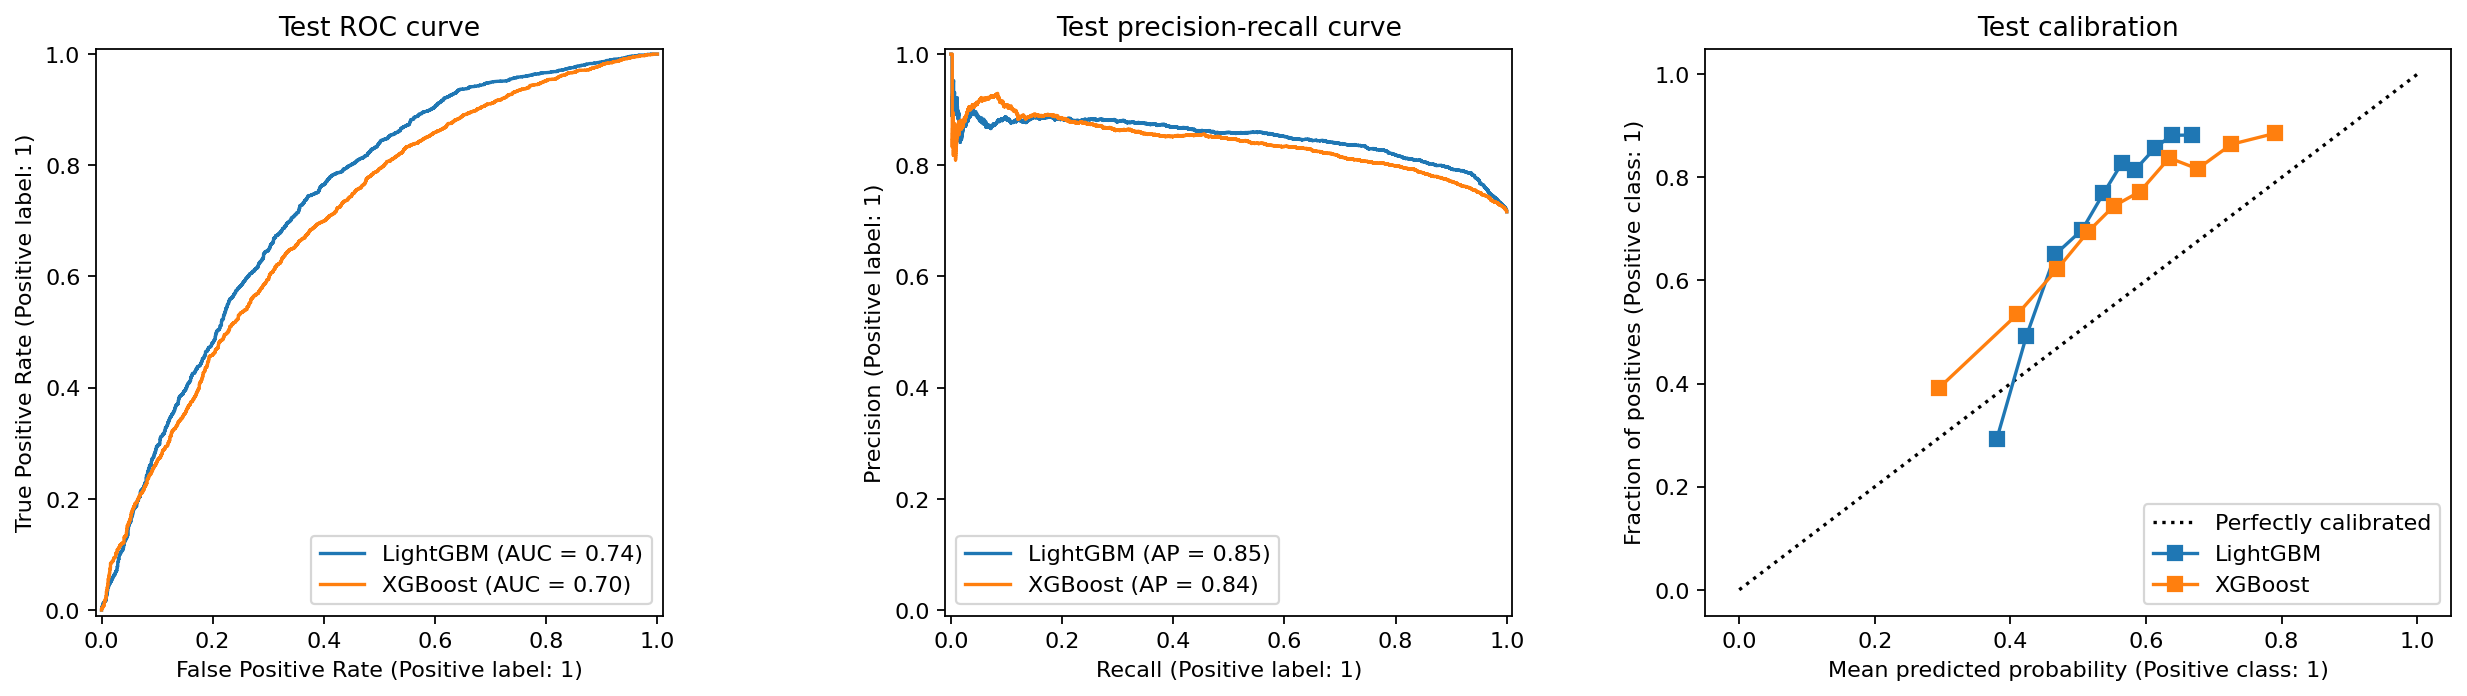

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for name, probability in [
    ('LightGBM', lightgbm_probability),
    ('XGBoost', xgboost_probability),
]:
    RocCurveDisplay.from_predictions(y_test, probability, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, probability, name=name, ax=axes[1])
    CalibrationDisplay.from_predictions(
        y_test, probability, n_bins=10, strategy='quantile', name=name, ax=axes[2]
    )
axes[0].set_title('Test ROC curve')
axes[1].set_title('Test precision-recall curve')
axes[2].set_title('Test calibration')
fig.tight_layout()
comparison_figure_path = OUTPUT_DIR / 'model_comparison.png'
fig.savefig(comparison_figure_path, dpi=160, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(comparison_figure_path)))

## 5. Do the models rely on similar signals?

Gain importance is model-specific and should not be read as a causal effect. It is useful here as a qualitative stability check: large disagreement can identify features or interactions worth investigating.

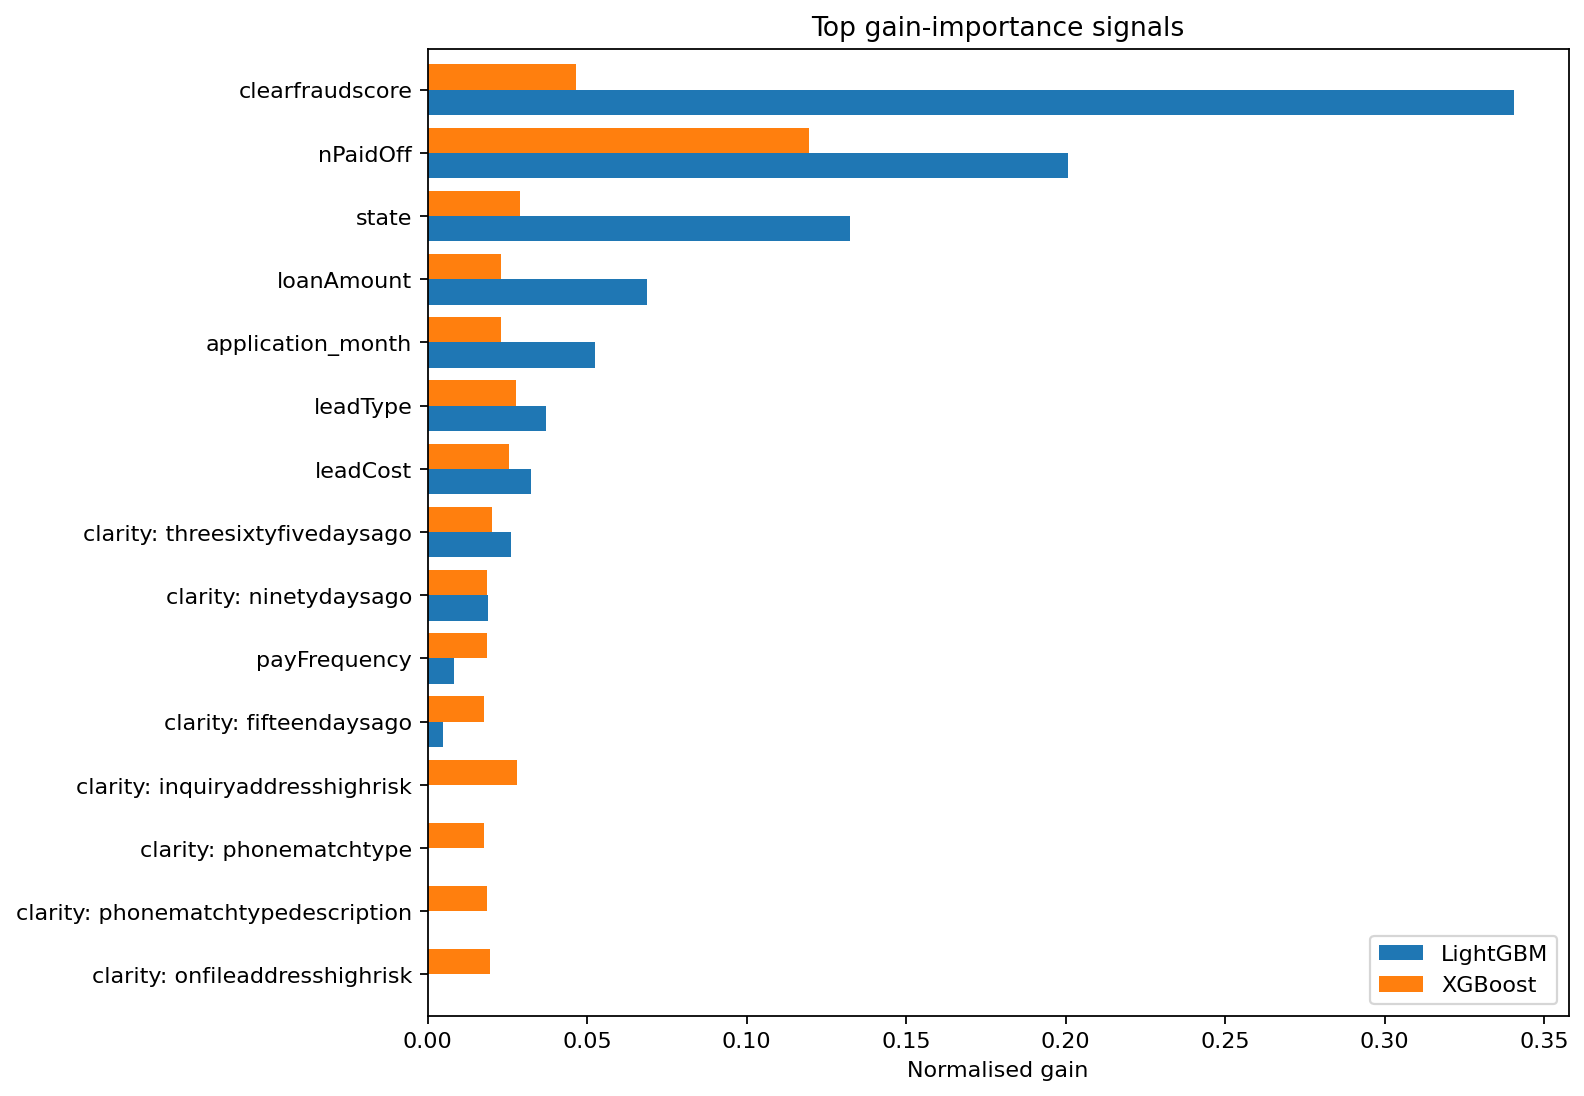

,LightGBM,XGBoost
feature,,
clearfraudscore,0.3406,0.0465
nPaidOff,0.2007,0.1196
state,0.1322,0.0290
loanAmount,0.0688,0.0231
application_month,0.0526,0.0231
leadType,0.0370,0.0277
leadCost,0.0324,0.0254
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,0.0261,0.0201
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,0.0189,0.0185


In [6]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'LightGBM': lightgbm_model.feature_importances_,
    'XGBoost': xgboost_model.feature_importances_,
}).set_index('feature')
for column in importance.columns:
    total = importance[column].sum()
    importance[column] = importance[column] / total if total else 0.0
importance['maximum'] = importance.max(axis=1)
top_importance = importance.nlargest(15, 'maximum').drop(columns='maximum').sort_values(
    'LightGBM'
)
def readable_feature_name(name):
    return name if len(name) <= 36 else f'clarity: {name.rsplit(".", 1)[-1]}'

plot_importance = top_importance.rename(index=readable_feature_name)
ax = plot_importance.plot.barh(figsize=(10, 7), width=0.8)
ax.set(title='Top gain-importance signals', xlabel='Normalised gain', ylabel='')
fig = ax.get_figure()
fig.tight_layout()
importance_figure_path = OUTPUT_DIR / 'feature_importance_comparison.png'
fig.savefig(importance_figure_path, dpi=160, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(importance_figure_path)))
top_importance.sort_values('LightGBM', ascending=False).round(4)

## 6. Evidence-led conclusion and interview wording

In [7]:
ranking_winner = comparison['roc_auc'].idxmax()
probability_winner = comparison['log_loss'].idxmin()
roc_delta = comparison.loc['XGBoost', 'roc_auc'] - comparison.loc['LightGBM', 'roc_auc']
pr_delta = comparison.loc['XGBoost', 'pr_auc'] - comparison.loc['LightGBM', 'pr_auc']
logloss_delta = comparison.loc['XGBoost', 'log_loss'] - comparison.loc['LightGBM', 'log_loss']

display(Markdown(f'''
### Result

- **Ranking winner in this controlled run:** {ranking_winner}.
- **Probability-quality winner by log loss:** {probability_winner}.
- XGBoost minus LightGBM: ROC-AUC **{roc_delta:+.4f}**, PR-AUC **{pr_delta:+.4f}**, log loss **{logloss_delta:+.4f}**.

### Suggested interview wording

“The submitted slides reflect the original time-boxed scope. After submission I added a controlled XGBoost sensitivity analysis. I froze the target, pre-pricing feature contract, chronological split, boosting budget, early stopping, and metrics, and changed only the estimator-specific configuration. On the held-out test period, {ranking_winner} ranked risk best, while {probability_winner} had the better log loss. This supports an evidence-led choice for this dataset, but it is not a universal claim about either library.”

### Limits

This notebook uses one defensible configuration per library rather than equal-budget hyperparameter optimisation or repeated temporal folds. Because the original test results were already inspected, this should be presented as a retrospective sensitivity analysis. Before changing the production champion, repeat model selection across rolling temporal validation windows, assess calibration and segment stability, and run the existing promotion and serving checks.
'''))


### Result

- **Ranking winner in this controlled run:** LightGBM.
- **Probability-quality winner by log loss:** XGBoost.
- XGBoost minus LightGBM: ROC-AUC **-0.0318**, PR-AUC **-0.0106**, log loss **-0.0199**.

### Suggested interview wording

“The submitted slides reflect the original time-boxed scope. After submission I added a controlled XGBoost sensitivity analysis. I froze the target, pre-pricing feature contract, chronological split, boosting budget, early stopping, and metrics, and changed only the estimator-specific configuration. On the held-out test period, LightGBM ranked risk best, while XGBoost had the better log loss. This supports an evidence-led choice for this dataset, but it is not a universal claim about either library.”

### Limits

This notebook uses one defensible configuration per library rather than equal-budget hyperparameter optimisation or repeated temporal folds. Because the original test results were already inspected, this should be presented as a retrospective sensitivity analysis. Before changing the production champion, repeat model selection across rolling temporal validation windows, assess calibration and segment stability, and run the existing promotion and serving checks.
